# Learn Python by *Talking* to AI — the `solveit` toolkit

This notebook is a hands-on tour of `solveit.py` — a tiny toolkit that turns a normal
Jupyter notebook into a place where you **learn Python by having a conversation with an AI**,
instead of copy-pasting prompts into a chat window.

It's inspired by Jeremy Howard's [SolveIt](https://solve.it.com) and George Pólya's
*How to Solve It* (1945). Four ideas drive everything here:

1. **Dialogue, not prompting** — talk *with* the AI over many small turns.
2. **Pólya's loop** — Understand → Plan → Do (tiny steps) → Review.
3. **Tiny steps + feedback** — write 1–2 lines, run them, look at the result, repeat.
4. **The human is the agent** — the AI *proposes*; **you** read, edit, and run.

> Make sure your `.env` has `ANTHROPIC_API_KEY` or `OPENAI_API_KEY`. `solveit` auto-detects
> whichever it finds.

## 0 · Setup

Import the toolkit. The snippet below finds `scripts/lib/` no matter where this notebook lives in the repo, then loads everything from `solveit`.

In [4]:
import sys, pathlib
# Make scripts/lib importable no matter where this notebook lives in the repo.
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / 'scripts' / 'lib').is_dir())
sys.path.append(str(_root / 'scripts' / 'lib'))

from solveit import *      # ask, tutor, solve, explain, hint, quiz, propose, anki, recap, ...
help_solveit()             # the full cheat-sheet

✅ **solveit loaded** · backend=`anthropic` · model=`claude-sonnet-4-6` · type `help_solveit()` for the cheat-sheet.

### 🧰 solveit toolkit — quick reference

| function | what it does |
|---|---|
| `ask("...")` | one-shot question, answer rendered as Markdown |
| `tutor.ask("...")` | **persistent** tutor dialogue (remembers context) |
| `solve("problem")` | start a **Pólya** session → `.understand() .plan() .step() .review()` |
| `explain(x)` | explain a value or snippet at beginner level |
| `explain_with_artifacts(x)` | explain **+ an interactive HTML artifact** rendered inline |
| `generate_visual_analogy("concept")` | AI-drawn **visual mnemonic** image, shown inline (Gemini / `gpt-image-2`) |
| `explain_error()` | explain the **last error** that occurred |
| `hint("...")` | a **Socratic** nudge — never the full answer |
| `quiz("topic")` | **interactive** quiz: type answers in boxes → AI-graded feedback |
| `review(code)` | review the student's *own* code |
| `propose("task")` | AI writes code into a **new editable cell** (you run it) |
| `%%edit <how>` | AI rewrites **this cell's** code in place + a comment |
| `edit(code, "how")` | same, but into a new cell |
| `cmd.<TAB>` | reusable custom prompts (`/commands`) — `cmd.eli5("loops")` |
| `cmd.add(name, tmpl)` | save your own command (persists across sessions) |
| `anki(focus="")` | export session to an **Anki**-importable `.txt` |
| `upload_pdf()` | **Upload-PDF button** → expands the whole PDF into a new reader notebook (cells + images), parsed by docling/pymupdf |
| `read_pdf("f.pdf")` | same, from a file path |
| `tutor.recap()` | **session summary** — what you covered & what to try next |

*The human is the agent: the AI proposes, **you** read, edit, and run.*

## 1 · `ask` — a single question, nicely rendered

The simplest tool. One question, one answer, rendered as Markdown right in the cell (answers **stream** in live).

In [2]:
ask("In one sentence, what is a Python list?")

A Python list is an ordered, mutable collection of elements enclosed in square brackets that can store items of different data types.

In [3]:
# Ok got it like this?
this_is_a_python_list = [10, "another element", 1.4]

In [6]:
quiz("How to use Python lists effectively for small scale automations:")

In [7]:
tasks = ['email', 'backup', 'report']
for i in range(len(tasks) + 1):
    print(tasks[i])

email
backup
report


IndexError: list index out of range

In [8]:
explain_error()

## "List index out of range" – Don't worry, this one's very common! 😊

---

### 1) What does it mean?

Imagine a **parking lot with 3 spaces**, numbered 0, 1, 2.
If you ask for space #5 — it doesn't exist!

Python is saying: *"You asked for an item that isn't in the list."*

---

### 2) Most likely causes

```python
fruits = ["apple", "banana", "cherry"]  # 3 items, positions 0, 1, 2
```

| Mistake | Example |
|---|---|
| Off by one | `fruits[3]` — last spot is `2`, not `3` |
| List is empty | `fruits = []` then `fruits[0]` |
| Wrong variable | Loop counter went too far |

---

### 3) How to fix it

**Quick check — print the length first:**
```python
print(len(fruits))   # tells you how many items exist
print(fruits)        # shows you what's actually inside
```

**Safe access pattern:**
```python
index = 3
if index < len(fruits):
    print(fruits[index])
else:
    print("That position doesn't exist!")
```

---

> 💡 **Remember:** A list with 3 items has positions **0, 1, 2** — never 3!

---

**Next step:** Can you paste the line of code that caused your error? I can help you pinpoint exactly what went wrong! 🙂

## 2 · `tutor` — a dialogue that *remembers*

This is the heart of SolveIt. Instead of one-shot prompts, hold a **conversation**.
`tutor` keeps the history, so each turn builds on the last.

In [9]:
tutor.ask("What is a dictionary in Python? Show me a real world example of a personal tool automation that uses it.")

Great question! A dictionary is like a **contact card** — it stores information in **label: value** pairs.

```python
contact = {
    "name": "Alice",
    "phone": "555-1234",
    "email": "alice@email.com"
}

print(contact["phone"])  # prints: 555-1234
```

- The **labels** (`"name"`, `"phone"`) are called **keys**
- The **values** are what's stored under each label

---

**Real automation example — a daily task tracker:**

```python
tasks = {
    "email": False,
    "backup": True,
    "report": False
}

for task, done in tasks.items():
    if not done:
        print(f"Still need to do: {task}")
```

This prints:
```
Still need to do: email
Still need to do: report
```

Notice how this connects to your quiz — you used a **list** for tasks before. A dictionary lets you also **track the status** of each task. That's the upgrade.

---

**Small question:** Can you guess how you'd mark `"email"` as done (i.e., change its value to `True`)? Give it a try! 😊

In [10]:
tutor.ask("Show me a tiny example.")   # it remembers the previous turn

Sure! Here's how you mark `"email"` as done:

```python
tasks["email"] = True
print(tasks["email"])  # prints: True
```

Think of it like **updating a contact's phone number** — you just point to the label and assign a new value.

---

Can you try doing the same for `"report"`? 😊

In [11]:
tutor.show()

**🧑 You:**

Can you review the code?

---

**🤖 AI:**

I'd love to help review your code! It looks like you might have forgotten to paste it. 😊

Go ahead and share it, and I'll take a look!

---

**🧑 You:**

We just did a quiz on 'How to use Python lists effectively for small scale automations:'. Here it is:
Q1 (recall): What method do you use to add a single item to the end of a Python list?
My answer: .append()
Q2 (predict): What will this code print?

tasks = ['email', 'backup', 'report']
tasks.remove('backup')
print(len(tasks))
My answer: 2
Q3 (bug): This code should print each task in the list, but it crashes. What is wrong?

tasks = ['email', 'backup', 'report']
for i in range(len(tasks) + 1):
    print(tasks[i])
My answer: the loop is going to run for more than the size of the list but it is being indexed with i which will be bigger than the listitself so index out of erorr

---

**🤖 AI:**

Got it — I have all the quiz questions and your answers in mind. Ask me about any of them.

---

**🧑 You:**

What is a dictionary in Python? Show me a real world example of a personal tool automation that uses it.

---

**🤖 AI:**

Great question! A dictionary is like a **contact card** — it stores information in **label: value** pairs.

```python
contact = {
    "name": "Alice",
    "phone": "555-1234",
    "email": "alice@email.com"
}

print(contact["phone"])  # prints: 555-1234
```

- The **labels** (`"name"`, `"phone"`) are called **keys**
- The **values** are what's stored under each label

---

**Real automation example — a daily task tracker:**

```python
tasks = {
    "email": False,
    "backup": True,
    "report": False
}

for task, done in tasks.items():
    if not done:
        print(f"Still need to do: {task}")
```

This prints:
```
Still need to do: email
Still need to do: report
```

Notice how this connects to your quiz — you used a **list** for tasks before. A dictionary lets you also **track the status** of each task. That's the upgrade.

---

**Small question:** Can you guess how you'd mark `"email"` as done (i.e., change its value to `True`)? Give it a try! 😊

---

**🧑 You:**

Show me a tiny example.

---

**🤖 AI:**

Sure! Here's how you mark `"email"` as done:

```python
tasks["email"] = True
print(tasks["email"])  # prints: True
```

Think of it like **updating a contact's phone number** — you just point to the label and assign a new value.

---

Can you try doing the same for `"report"`? 😊

## 3 · `explain`, `hint`, `explain_error` — learning helpers

- `explain(x)` — explain a value or snippet at a beginner level.
- `hint(...)` — a **Socratic** nudge that never gives the full answer (great for exercises).
- `explain_error()` — explain the **last error** that happened, in plain English.

In [12]:
explain("for i in range(3): print(i)")

## What this code does

It **counts and prints the numbers 0, 1, 2**.

```
0
1
2
```

---

**Line by line:**

- `range(3)` — makes a list of 3 numbers: `0, 1, 2` (starts at 0, stops *before* 3)
- `for i in range(3)` — like dealing cards one at a time; each number gets placed into `i` for a turn
- `print(i)` — prints whatever number `i` is holding right now

---

**Analogy:** Think of a vending machine with slots 0, 1, 2. The loop visits each slot and reads the number out loud.

---

**Try it:** What do you think `range(5)` would print? Give it a guess, then run it! 🙂

In [13]:
hint("I want to reverse a list but I don't know which method to use")

Great question! Here's a nudge:

If you had a physical stack of cards and wanted to reverse the order, what would you do — pick from the **top** or the **bottom** first?

Now, can you think of a Python list method (or maybe a built-in function) whose name literally sounds like "going backwards"? 🤔

Run the next cell (it will raise an error **on purpose**), then run the cell after it:

In [14]:
nums = [1, 2, 3]
print(nums[5])      # IndexError on purpose

IndexError: list index out of range

In [15]:
explain_error()     # explains the error from the cell above

## IndexError: list index out of range

### 1) What it means in plain English
A list is like a numbered row of boxes. This error means you asked Python to open box number X, **but that box doesn't exist**. Maybe your list only has 3 boxes, but you tried to open box 5.

---

### 2) Most likely causes

- **Off-by-one:** Lists start at index `0`, not `1`
- **Empty list:** You're indexing a list that has nothing in it
- **Wrong number:** You hardcoded an index that's too big
- **Loop went too far:** Your loop ran one step past the end

---

### 3) How to fix it

**Quick check — print the length first:**
```python
fruits = ["apple", "banana"]
print(len(fruits))   # 2 items → valid indexes are 0 and 1
print(fruits[2])     # 💥 Error! Box 2 doesn't exist
print(fruits[1])     # ✅ Works fine
```

**Safe fix — check before accessing:**
```python
i = 2
if i < len(fruits):
    print(fruits[i])
else:
    print("Index is too big!")
```

---

> 💡 **Remember:** A list with **3 items** has indexes **0, 1, 2** — never 3.

---

**Next step:** Can you paste your code here? I can show you exactly which line is the culprit! 😊

In [17]:
propose("I want to automate slide deck generation with Python, but I'm a beginner at python, propose something to help me get started")

🤖 *Proposed code dropped into a new cell below — read it, edit it, then run it yourself.*

In [2]:
# # 🤖 PROPOSED (review & edit before running)
# from pptx import Presentation  # pip install python-pptx

# prs = Presentation()  # create a new empty presentation

# slide = prs.slides.add_slide(prs.slide_layouts[1])  # layout 1 = title + content

# slide.shapes.title.text = "My First Slide"
# slide.placeholders[1].text = "Hello! This slide was made with Python."

# prs.save("my_presentation.pptx")  # saves the file in your current folder
# print("Done! Open my_presentation.pptx to see it.")

/Users/greatmaster/Desktop/projects/oreilly-live-trainings/oreilly-python-course/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## 4 · `solve` — work a problem with Pólya's loop

`solve(problem)` starts a guided session. Call the stages in order — each one is a small
step in the dialogue, and the AI coaches your thinking instead of dumping a full solution.

In [ ]:
p = solve("Count how many words are in a sentence")
p.understand()    # restate the problem, surface unknowns

In [ ]:
p.plan()     # a short plain-English plan, no code yet

In [ ]:
p.step()     # the single smallest next step to try

In [ ]:
p.review()   # once you have something working, look back

## 5 · `propose` & `edit` — the AI writes, *you* run

The SolveIt move: the AI **proposes** code into a **new editable cell** below — it does
**not** run it. You read it, tweak it, and decide to run it yourself.

In [5]:
propose("read a CSV file called data.csv into a list of rows")

🤖 *Proposed code dropped into a new cell below — read it, edit it, then run it yourself.*

In [8]:
tutor.ask("""
Change this code to use pandas and generate a simple visualization of the code
# 🤖 PROPOSED (review & edit before running)
import csv

with open("../../../assets/synthetic_sales_data.csv", newline="") as f:  # newline="" keeps line endings consistent
    reader = csv.reader(f)
    rows = list(reader)  # each row becomes a list of values

print(rows)
""")

Here's the updated code using pandas with a simple visualization:

```python
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("../../../assets/synthetic_sales_data.csv")

# Quick peek at the data
print(df.head())

# Simple bar chart of the first numeric column grouped by first text column
df.groupby(df.columns[0])[df.columns[1]].sum().plot(kind="bar")

plt.title("Sales Summary")
plt.tight_layout()
plt.show()
```

**What each part does:**

| Line | What it does |
|------|-------------|
| `pd.read_csv(...)` | Reads the file into a **DataFrame** (think: a spreadsheet in Python) |
| `df.head()` | Shows the first 5 rows so you can see the data |
| `df.groupby(...)` | Groups rows by the first column (like a category) |
| `.plot(kind="bar")` | Draws a bar chart |

> **Note:** The chart auto-picks the first two columns. Once you run `print(df.head())`, share what columns you see — then we can make the chart show exactly what's most useful! 📊

What does your data look like when you run `df.head()`?

In [10]:
tutor.ask("Make sure it uses the units_sold column")

```python
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("../../../assets/synthetic_sales_data.csv")

# Quick peek at the data
print(df.head())

# Bar chart of units_sold grouped by the first column
df.groupby(df.columns[0])["units_sold"].sum().plot(kind="bar")

plt.title("Units Sold Summary")
plt.xlabel(df.columns[0])
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()
```

**The one key change:**

```python
# Before (auto-picked column)
df.groupby(df.columns[0])[df.columns[1]].sum()

# After (specifically uses units_sold)
df.groupby(df.columns[0])["units_sold"].sum()
```

We just replaced `df.columns[1]` with `"units_sold"` — like calling someone by their name instead of "the second person in line". 😊

What column is being used for the grouping (the x-axis)? We can swap that out too if needed!

   order_date  order_id   region              city product_category  \
0  2025-01-01  ORD-0349    North  Viana do Castelo      Electronics   
1  2025-01-03  ORD-0266  Central           Cascais             Home   
2  2025-01-03  ORD-0012    North  Viana do Castelo          Fitness   
3  2025-01-03  ORD-0250     West            Leiria             Home   
4  2025-01-04  ORD-0087    South           Setúbal             Home   

          product sales_channel customer_segment sales_rep  units_sold  \
0          Laptop       Partner       Enterprise     Tiago           3   
1  Coffee Machine        Retail       Enterprise     Diogo          11   
2       Dumbbells        Online              SMB     Marta           3   
3  Coffee Machine       Partner       Enterprise     Tiago           7   
4       Desk Lamp        Retail              SMB      Joao          10   

   unit_price  discount_pct  revenue  profit_margin_pct  profit  
0     1253.67          0.00  3761.01               0.14  526.5

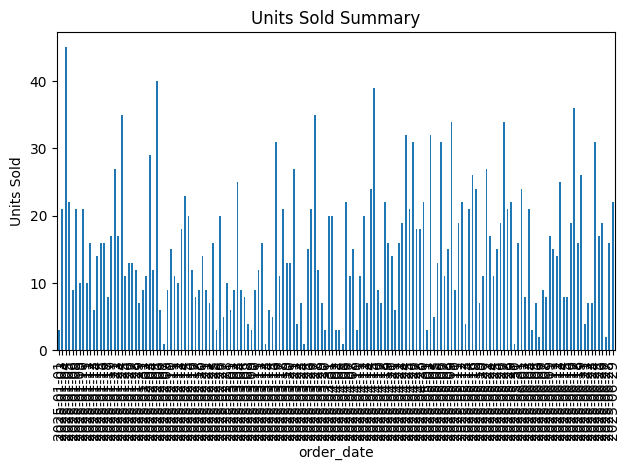

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv("../../../assets/synthetic_sales_data.csv")

# Quick peek at the data
print(df.head())

# Bar chart of units_sold grouped by the first column
df.groupby(df.columns[0])["units_sold"].sum().plot(kind="bar")

plt.title("Units Sold Summary")
plt.xlabel(df.columns[0])
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

`edit(code, "how")` rewrites a snippet into a new cell. There's also a `%%edit <instruction>` cell-magic that rewrites *the current cell* in place.

In [12]:
edit("for i in range(len(xs)): print(xs[i])", "make it pythonic")

In [ ]:
# ✏️ EDIT: Loop directly over the list instead of using index tricks — Python lets you do this cleanly.
for x in xs:
    print(x)

## 6 · `quiz` — an interactive check-for-understanding

Generates questions, gives you boxes to type answers, and the AI grades them with full
knowledge of both the questions *and* your answers. The `tutor` remembers the quiz too.

In [ ]:
quiz("Python variables and f-strings", n=3)

## 7 · `cmd` — reusable custom prompts (your own `/commands`)

Type `cmd.` then **TAB** to discover them. A few ship by default; you can add your own and
they persist across sessions.

In [ ]:
cmd.eli5("recursion")

In [ ]:
# cmd.add("roast", "Roast my Python code, then fix it kindly:\n{input}")
# cmd.list()

## 8 · `anki` & `recap` — close the loop

- `anki(focus="...")` turns this session into an **Anki-importable** `.txt` of flashcards.
- `recap()` writes a warm, structured **summary** of everything you did and what to try next.

This is Pólya's *"look back"* — and it's how the learning sticks.

In [ ]:
anki(focus="lists and dictionaries", n=6)

In [13]:
recap()

## 📚 What we covered
You worked with reading a CSV file in Python, then leveled up by switching to **pandas** to handle the data more powerfully. You also took your first step into **data visualization** using matplotlib.

## 💡 Key takeaways
- The built-in `csv` module can read CSV files, but pandas makes it much easier with `pd.read_csv()`
- pandas loads your data into a **DataFrame** — think of it like a spreadsheet you can work with in code
- `df.head()` is a handy way to peek at the first few rows of your data
- You can loop directly over a list in Python — no index tricks needed
- matplotlib's `plt` lets you turn data into charts with just a few lines

## 🛠️ What you practiced
You started with a basic CSV-reading script, then rewrote it to use pandas and matplotlib. You also made sure the chart used a specific column — `units_sold` — which meant reading the code carefully and directing the changes yourself.

## 🎯 Suggested next steps
1. **Try `df.describe()`** on your DataFrame to see quick stats (average, min, max) for `units_sold`
2. **Swap the bar chart for a line chart** by changing `kind="bar"` to `kind="line"` and see how it looks
3. **Filter the data** — try plotting only rows where `units_sold` is above a certain number using `df[df["units_sold"] > 50]`

## 🌟 Nice work
You didn't just accept the first solution — you pushed further to make sure the visualization used exactly the column you wanted, and that kind of precision is a real programmer's instinct!

## Bonus · learning from PDFs and visual mnemonics

- `read_pdf("paper.pdf")` (or `upload_pdf()` for a button) expands a whole PDF into a **new
  reader notebook** — each section becomes a cell with a chat cell beneath it.
- `generate_visual_analogy("a dict maps keys to values")` draws a memorable image for a concept.

```python
generate_visual_analogy("Python list indexing starts at 0")
upload_pdf()
```

---

**Remember the one rule:** the AI proposes — *you* read, edit, and run. You're the agent.